# Some study of unitary Krylov coverage versus dt

Cannot tell what minmax is from a quick glance

In [1]:
import os
import sys
from pathlib import Path
from functools import partial
import logging
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import eigh, eigvalsh
from scipy.optimize import curve_fit
import h5py
import jax
import jax.numpy as jnp
from jax.sharding import PartitionSpec, NamedSharding
from jax.experimental.ode import odeint
from qiskit.quantum_info import SparsePauliOp
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.parameters import Parameters
from skqd_z2lgt.extensions import denoising, perturbation_2q
from skqd_z2lgt.circuits import make_plaquette_circuits
from skqd_z2lgt.mwpm import minimum_weight_link_state
from skqd_z2lgt.sqd import sqd
from skqd_z2lgt.utils import read_bits
from skqd_z2lgt.tasks.common import make_dual_lattice
from skqd_z2lgt.jax_experimental_sparse_linalg import lobpcg_standard
sys.path.append('/home/iiyama/src/skqd_z2lgt/lib')
from unitary_krylov import make_hvec, make_trotter_uvec, integrate, simulate, sample, exact_diag, compute_gen_eigvals

logging.basicConfig(level=logging.INFO)
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2,4,5,6'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
jax.config.update('jax_enable_x64', True)

LOG = logging.getLogger()

In [ ]:
# Links to excite for equator-slicing charge positioning
excited_links = {
    (4, 1): [5],
    (4, 2): [8],
    (4, 3): [11, 13],
    (4, 4): [14, 16],
    (4, 5): [17, 19, 22],
    (4, 6): [20, 22, 25],
    # (4, 7): [23, 25, 28, 31],
    (6, 1): [],
    (6, 2): [12],
    (6, 3): [17],
    (6, 4): [21, 24],
    # (6, 5): [26, 29],
    (8, 1): [10],
    (8, 2): [16],
    (8, 3): [22, 24]
}

In [3]:
@partial(jax.jit, static_argnums=[0, 1])
def compute_ground_state(hvec, nplaq, alpha):
    xmat = jax.nn.one_hot(0, 2 ** nplaq, dtype=np.complex128)[:, None]
    # pylint: disable-next=unbalanced-tuple-unpacking
    vecs = lobpcg_standard(lambda x: -hvec(x.T).T, xmat)[1]
    probs = jnp.square(jnp.abs(vecs[:, 0]))
    sort_idx = jnp.argsort(probs, descending=True)
    sorted_probs = jnp.sort(probs, descending=True)
    cum_probs = jnp.cumsum(sorted_probs)
    cutoff_idx = jnp.searchsorted(cum_probs, alpha)
    return sort_idx, sorted_probs, cutoff_idx

@partial(jax.jit, static_argnums=[0, 1])
def compute_krylov_vectors(hvec, nplaq, tpoints, sort_idx, psi0=None):
    return integrate(hvec, nplaq, tpoints, psi0=psi0)[1:, sort_idx]

@partial(jax.jit, static_argnums=[0, 1])
def compute_krylov(hvec, nplaq, tpoints, sort_idx):
    psis = compute_krylov_vectors(hvec, nplaq, tpoints, sort_idx)
    return jnp.square(jnp.abs(psis))

def krylov_hstack(config, plaquette_energy, alpha, dtvals, max_steps):
    LOG.info('Config %s', config)
    lattice = TriangularZ2Lattice(config)
    nplaq = lattice.num_plaquettes

    base_link_state = np.zeros(lattice.num_links, dtype=np.uint8)
    base_link_state[::-1][excited_links[config]] = 1
    dual_lattice = lattice.plaquette_dual(base_link_state)
    hamiltonian = dual_lattice.make_hamiltonian(plaquette_energy)
    hvec = make_hvec(hamiltonian)

    LOG.info('compute_ground_state')
    sort_idx, sorted_probs, cutoff_idx = compute_ground_state(hvec, nplaq, alpha)
    cutoff_idx = int(cutoff_idx)
    LOG.info('cutoff index %d', cutoff_idx)
    sort_idx = sort_idx[:cutoff_idx]
    sorted_probs = sorted_probs[:cutoff_idx]

    krylov_probs = np.empty(dtvals.shape + (max_steps, cutoff_idx))
    for idt, dt in enumerate(dtvals):
        if config == (4, 7):
            psi0 = None
            with jax.default_device(jax.devices()[1]):
                hvec = make_hvec(hamiltonian)
                for istep in range(max_steps):
                    tpoints = np.array([dt * istep, dt * (istep + 1)])
                    LOG.info('compute_krylov_vectors(%d, %d)', idt, istep)
                    psi0 = compute_krylov_vectors(hvec, nplaq, tpoints, sort_idx, psi0=psi0)[0]
                    krylov_probs[idt, istep] = np.square(np.abs(psi0))
        else:
            tpoints = np.linspace(0., max_steps * dt, max_steps + 1)
            LOG.info('compute_krylov(%d)', idt)
            krylov_probs[idt] = compute_krylov(hvec, nplaq, tpoints, sort_idx)

    return sorted_probs, krylov_probs

In [4]:
plaquette_energy = 0.5
alpha = 0.9999
dtvals = np.linspace(np.pi / 15., np.pi / 5., 11)
with h5py.File('/data/iiyama/2dz2/krylov_hstack.h5', 'a', libver='latest') as out:
    if 'plaquette_energy' not in out:
        out.create_dataset('plaquette_energy', data=plaquette_energy)
        out.create_dataset('alpha', data=alpha)
        out.create_dataset('dt', data=dtvals)
    for config in excited_links.keys():
        group_name = f'row{config[0]}_col{config[1]}'
        if group_name not in out:
            sorted_probs, krylov_probs = krylov_hstack(config, plaquette_energy, alpha, dtvals, 8)
            group = out.create_group(group_name)
            group.create_dataset('ground_state', data=sorted_probs)
            group.create_dataset('krylov', data=krylov_probs)

INFO:root:Config (4, 7)
INFO:root:compute_ground_state
INFO:2025-12-24 13:28:54,756:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:root:cutoff index 35195
INFO:root:compute_krylov_vectors(0, 0)
2025-12-24 13:29:38.637871: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3183] Can't reduce memory use below 56.46GiB (60629261052 bytes) by rematerialization; only reduced to 68.00GiB (73015138688 bytes), down from 68.00GiB (73015138688 bytes) originally
2025-12-24 13:29:51.855875: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_1_bfc) ran out of memory trying to allocate 68.00GiB (rounded to 73014450432)requested by op 
If the cause is memory fragmentation maybe

XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 73014450248 bytes.

In [51]:
minmax = {}
beta = {}
with h5py.File('/data/iiyama/2dz2/krylov_hstack.h5', 'r', libver='latest') as source:
    dtvals = source['dt'][()]
    for config in excited_links.keys():
        group = source[f'row{config[0]}_col{config[1]}']
        ground_state = group['ground_state'][()]
        krylov = group['krylov'][()]
        cum_probs = np.cumsum(ground_state)
        s2 = np.searchsorted(cum_probs, 0.99)
        beta[config] = ground_state[s2]
        minmax[config] = np.empty(krylov.shape[:2])
        for istep in range(1, krylov.shape[1] + 1):
            minmax[config][:, istep - 1] = np.min(np.max(krylov[:, :istep, :s2], axis=1), axis=-1)

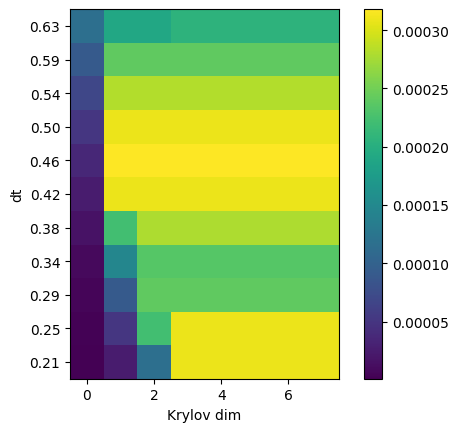

In [52]:
plt.imshow(minmax[(6, 4)], origin='lower')
plt.yticks(np.arange(dtvals.shape[0]), [f'{dt:.2f}' for dt in dtvals])
plt.xlabel('Krylov dim')
plt.ylabel('dt')
plt.colorbar()

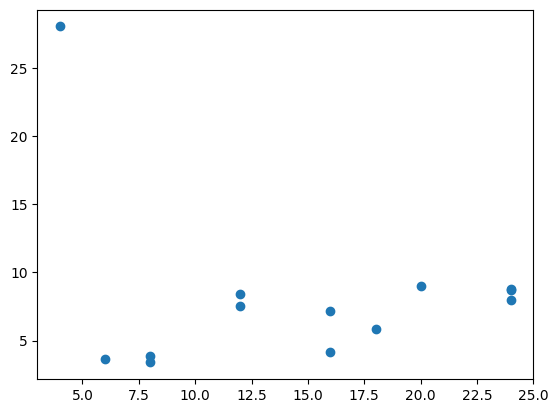

In [53]:
nplaq = []
ratio = []
for config, betaval in beta.items():
    nplaq.append(np.prod(config))
    ratio.append(np.max(minmax[config]) / betaval)

plt.scatter(nplaq, ratio)

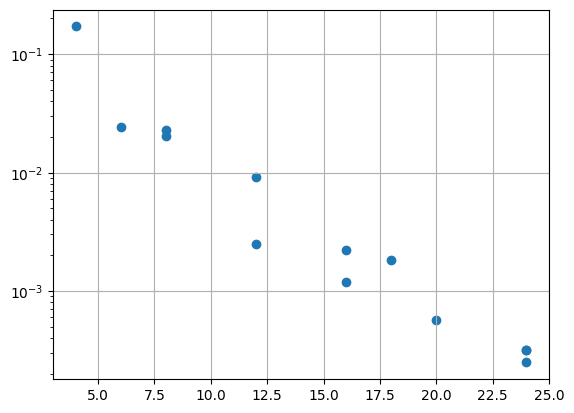

In [54]:
nplaq = []
prob = []
for config, betaval in beta.items():
    nplaq.append(np.prod(config))
    prob.append(np.max(minmax[config]))

plt.scatter(nplaq, prob)
plt.grid()
plt.yscale('log')

In [39]:
minmax[(6, 4)][:, -1]

array([0.00030835, 0.00030823, 0.0002403 , 0.00023447, 0.00027938,
       0.00030835, 0.00031807, 0.00030823, 0.00028095, 0.0002403 ,
       0.00020638])

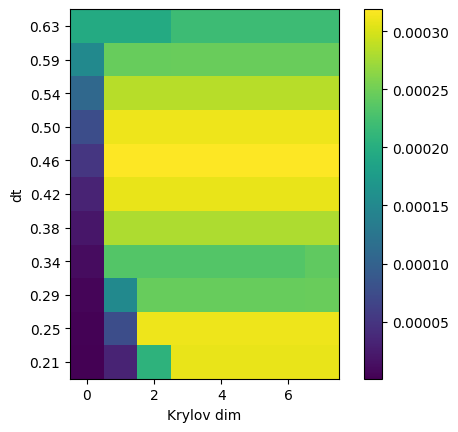

In [36]:
plt.imshow(minmax[(8, 3)], origin='lower')
plt.yticks(np.arange(dtvals.shape[0]), [f'{dt:.2f}' for dt in dtvals])
plt.xlabel('Krylov dim')
plt.ylabel('dt')
plt.colorbar()

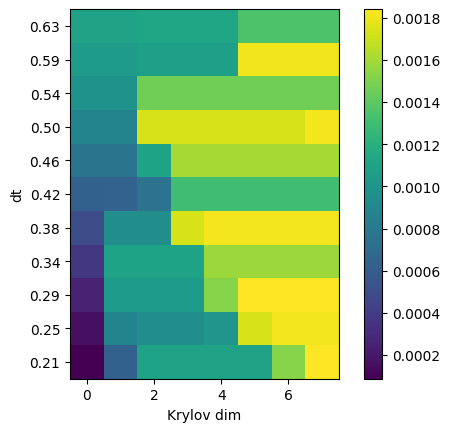

In [37]:
plt.imshow(minmax[(6, 3)], origin='lower')
plt.yticks(np.arange(dtvals.shape[0]), [f'{dt:.2f}' for dt in dtvals])
plt.xlabel('Krylov dim')
plt.ylabel('dt')
plt.colorbar()

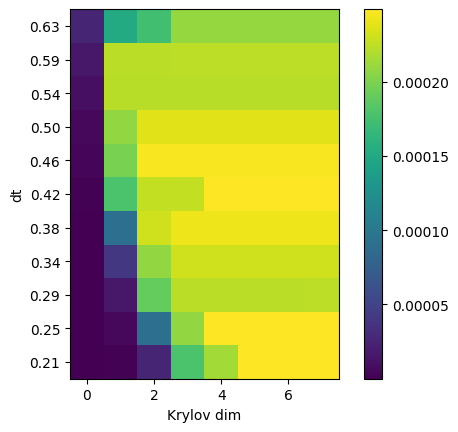

In [47]:
plt.imshow(minmax[(4, 6)], origin='lower')
plt.yticks(np.arange(dtvals.shape[0]), [f'{dt:.2f}' for dt in dtvals])
plt.xlabel('Krylov dim')
plt.ylabel('dt')
plt.colorbar()

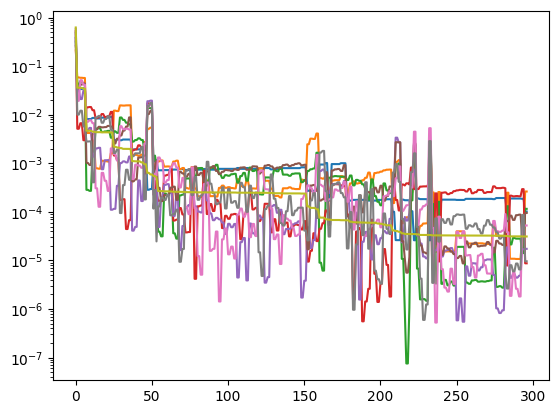

In [ ]:
plt.plot(krylov[-1, :, :s2].T)
plt.plot(ground_state[:s2])
plt.yscale('log')

In [27]:
ground_state[s2]

np.float64(3.1132318644550354e-05)

In [3]:
plaquette_energy = 0.5
max_steps = 8

filename = '/data/iiyama/2dz2/krylov_hstack.h5'

probs_grounds = {i: [] for i in [4, 6, 8]}
spectra = {i: [] for i in [4, 6, 8]}
probs_krylovs = {i: [] for i in [4, 6, 8]}

if os.path.exists(filename):
    with h5py.File(filename, 'r', libver='latest') as source:
        for rows in [4, 6, 8]:
            largems[rows] = source[f'row{rows}/largem'][()]
            for iconfig in range(len(configs[rows])):
                sg = f'row{rows}/col{iconfig + 1}'
                probs_grounds[rows].append(source[f'{sg}/probs_ground'][()])
                spectra[rows].append(source[f'{sg}/spectrum'][()])
                probs_krylovs[rows].append(source[f'{sg}/probs_krylov'][()])

else:
    for rows in [4, 6, 8]:
        for iconfig, (config, links) in enumerate(zip(configs[rows], excited_links[rows])):
            cols = iconfig + 1
            lattice = TriangularZ2Lattice(config)
            nplaq = lattice.num_plaquettes

            base_link_state = np.zeros(lattice.num_links, dtype=np.uint8)
            base_link_state[::-1][links] = 1
            dual_lattice = lattice.plaquette_dual(base_link_state)
            hamiltonian = dual_lattice.make_hamiltonian(plaquette_energy)

            eigvals, eigvecs = jnp.linalg.eigh(hamiltonian.to_matrix().real)
            spectra[rows].append(eigvals)

            probs_ground = np.square(np.abs(eigvecs[:, 0]))
            probs_grounds[rows].append(probs_ground)
            largem = np.nonzero(np.square(np.abs(eigvecs[0])) > gammasq_cutoff)[0][-1]
            largems[rows].append(largem)

            dt = np.pi / (eigvals[largem] - eigvals[0])
            tpoints = np.linspace(0., max_steps * dt, max_steps + 1)
            hvec = make_hvec(hamiltonian)
            psis = integrate(hvec, nplaq, tpoints)
            probs_krylov = np.square(np.abs(psis))
            probs_krylovs[rows].append(probs_krylov)

    with h5py.File(filename, 'w', libver='latest') as out:
        for rows in [4, 6, 8]:
            group = out.create_group(f'row{rows}')
            group.create_dataset('largem', data=largems[rows])
            for iconfig in range(len(configs[rows])):
                subgroup = group.create_group(f'col{iconfig + 1}')
                subgroup.create_dataset('probs_ground', data=probs_grounds[rows][iconfig])
                subgroup.create_dataset('spectrum', data=spectra[rows][iconfig])
                subgroup.create_dataset('probs_krylov', data=probs_krylovs[rows][iconfig])

In [5]:
spectra

{4: [array([-9.31320947, -7.08276253, -6.93535577, -3.23044694, -3.23044694,
         -1.        , -1.        , -0.99972236, -0.85259323, -0.85259323,
          2.85231559,  5.08276253,  5.08304017,  5.08304017,  5.2301693 ,
         11.1658027 ]),
  array([-15.4851948 , -13.33103118, -13.18057395, -11.33284478,
         -11.33114368,  -9.68745853,  -9.68745675,  -9.46289969,
          -9.46289933,  -9.28136488,  -9.28128579,  -9.18606543,
          -9.18600882,  -7.55426074,  -7.55423246,  -7.46063252,
          -7.42478555,  -7.37531356,  -7.31409438,  -7.27525692,
          -7.24492586,  -7.24312979,  -7.24140869,  -7.20479282,
          -7.15163928,  -7.14752794,  -6.99116113,  -6.99116014,
          -6.82556851,  -6.82555711,  -5.61013067,  -5.45586703,
          -5.41633957,  -5.28905366,  -5.2721055 ,  -5.22352329,
          -5.22352167,  -5.19457407,  -5.09600034,  -5.09283856,
          -5.08171003,  -5.03833186,  -5.01754455,  -5.0175445 ,
          -5.00691361,  -5.0069136 ,

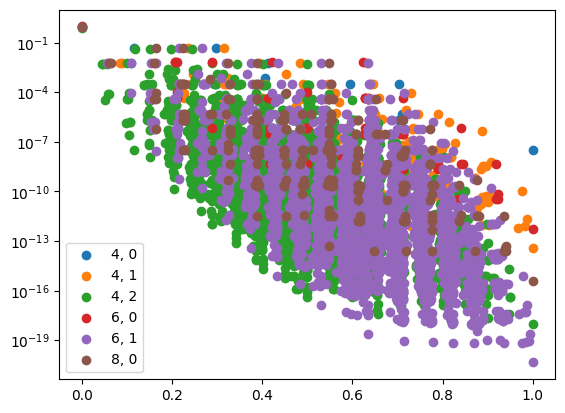

In [9]:
for rows, iconfig in [(4, 0), (4, 1), (4, 2), (6, 0), (6, 1), (8, 0)]:
    norm = np.max(spectra[rows][iconfig]) - np.min(spectra[rows][iconfig])
    plt.scatter((spectra[rows][iconfig] - spectra[rows][iconfig][0]) / norm, probs_grounds[rows][iconfig], label=f'{rows}, {iconfig}')
plt.yscale('log')
plt.legend();

In [10]:
largems[6][1]

np.int64(107)

In [11]:
spectra[6][1].shape

(4096,)

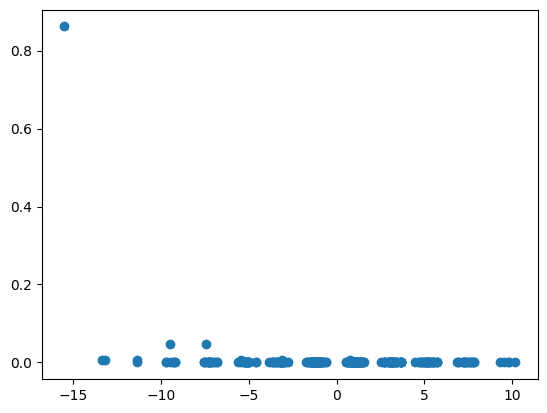

In [7]:
plt.scatter(spectra[4][1], probs_grounds[4][1])

In [5]:
system_sizes = []
min_prob_s2 = []
min_prob_s3 = []
min_prob_s4 = []
for rows in [4, 6, 8]:
    for iconfig, (probs_ground, probs_krylov) in enumerate(zip(probs_grounds[rows], probs_krylovs[rows])):
        system_sizes.append(rows * (iconfig + 1))
        sort_idx_ground = np.argsort(probs_ground)[::-1]
        sorted_probs_ground = np.sort(probs_ground)[::-1]
        cum_probs_ground = np.cumsum(sorted_probs_ground)
        s2 = np.searchsorted(cum_probs_ground, 0.99)
        s3 = np.searchsorted(cum_probs_ground, 0.999)
        s4 = np.searchsorted(cum_probs_ground, 0.9999)
        min_prob_s2.append(np.min(np.max(probs_krylov[:, sort_idx_ground[:s2]], axis=0)))
        min_prob_s3.append(np.min(np.max(probs_krylov[:, sort_idx_ground[:s3]], axis=0)))
        min_prob_s4.append(np.min(np.max(probs_krylov[:, sort_idx_ground[:s4]], axis=0)))

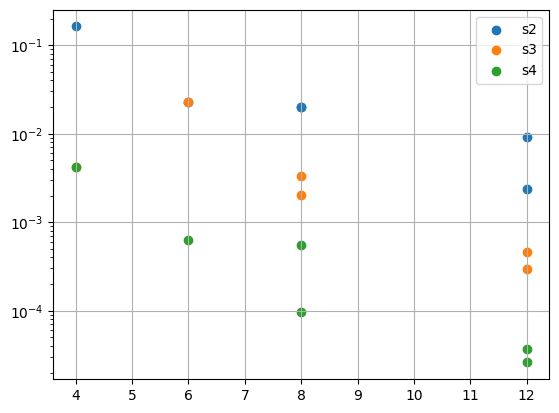

In [6]:
plt.scatter(system_sizes, min_prob_s2, label='s2')
plt.scatter(system_sizes, min_prob_s3, label='s3')
plt.scatter(system_sizes, min_prob_s4, label='s4')
plt.yscale('log')
plt.grid()
plt.legend();

In [16]:
maxmin = []
for rows in [4, 6, 8]:
    for iconfig, sp in enumerate(spectra[rows]):
        maxmin.append(sp[-1] + sp[0])
        print(rows, iconfig + 1, sp[0], sp[-1])

4 1 -9.313209465803542 11.165802700596824
4 2 -15.485194800264136 10.156951580915278
4 3 -20.806203894903753 20.814247416818887
6 1 -16.24884287089539 12.543656401308844
6 2 -23.651850181225015 14.626299759838828
8 1 -19.479289806400704 17.626696571607432


In [13]:
spectra[4][0]

array([-9.31320947, -7.08276253, -6.93535577, -3.23044694, -3.23044694,
       -1.        , -1.        , -0.99972236, -0.85259323, -0.85259323,
        2.85231559,  5.08276253,  5.08304017,  5.08304017,  5.2301693 ,
       11.1658027 ])

In [19]:
for rows in [4, 6, 8]:
    for iconfig, sp in enumerate(spectra[rows]):
        print(sp[1] - sp[0])

2.2304469355053174
2.1541636226818888
1.843627295793837
5.93563340509186
2.1541622972205197
2.230446935505313


In [18]:
largems

{4: array([  9,  55, 368]), 6: array([ 10, 107]), 8: array([31])}

In [ ]:
probs_ground = probs_grounds[4][0]
sort_idx_ground = np.argsort(probs_ground)[::-1]
sorted_probs_ground = np.sort(probs_ground)[::-1]
cum_probs_ground = np.cumsum(sorted_probs_ground)
s2 = np.searchsorted(cum_probs_ground, 0.99)
s3 = np.searchsorted(cum_probs_ground, 0.999)
s4 = np.searchsorted(cum_probs_ground, 0.9999)

In [20]:
s2, s3, s4

(np.int64(3), np.int64(7), np.int64(9))

In [22]:
probs_ground[sort_idx_ground]

array([8.91096818e-01, 4.73224006e-02, 4.73224006e-02, 6.10368922e-03,
       6.10368922e-03, 6.98586082e-04, 3.24141238e-04, 3.24141238e-04,
       3.24141238e-04, 3.24141238e-04, 4.18080520e-05, 4.78506067e-06,
       4.78506067e-06, 2.22024963e-06, 2.22024963e-06, 3.27759258e-08])

In [26]:
probs_krylov = probs_krylovs[4][0]
np.max(probs_krylov[:, sort_idx_ground[:s3]], axis=0)

array([1.        , 0.16252754, 0.16252754, 0.02619477, 0.02619477,
       0.00450049, 0.00419364])

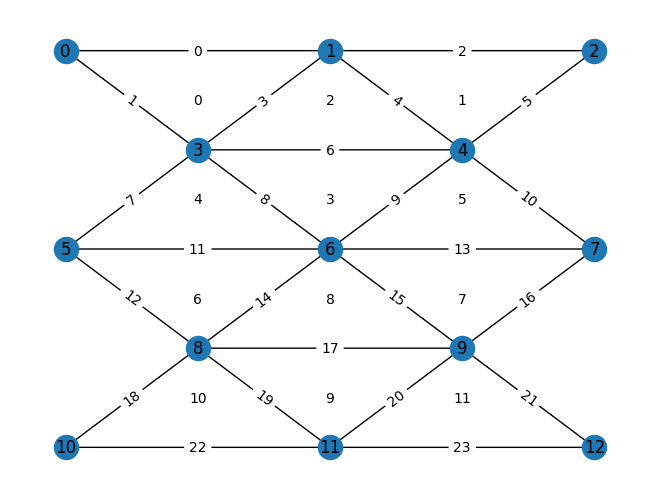

In [ ]:
rows, cols = 4, 3
plaquette_energy = 0.5

config = configs[rows][cols - 1]
lattice = TriangularZ2Lattice(config)
lattice.draw_graph();

In [4]:
nplaq = lattice.num_plaquettes
base_link_state = np.zeros(lattice.num_links, dtype=np.uint8)
base_link_state[::-1][excited_links[rows][cols - 1]] = 1
dual_lattice = lattice.plaquette_dual(base_link_state)
hamiltonian = dual_lattice.make_hamiltonian(0.5)

In [5]:
eigvals, eigvecs = jnp.linalg.eigh(hamiltonian.to_matrix().real)

INFO:2025-12-19 15:03:52,539:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


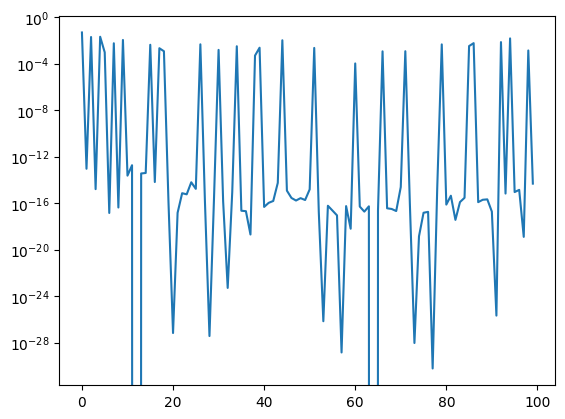

In [17]:
plt.plot(np.abs(eigvecs[0, 100:200]))
plt.yscale('log')

In [26]:
largem = np.nonzero(np.square(np.abs(eigvecs[0])) > 1.e-4)[0][-1]
largem

np.int64(368)

In [27]:
eigvals[largem] - eigvals[0]

Array(12.76151064, dtype=float64)

In [29]:
probs_ground = np.square(np.abs(eigvecs[:, 0]))
sort_idx_ground = np.argsort(probs_ground)[::-1]
sorted_probs_ground = np.sort(probs_ground)[::-1]

In [30]:
cum_probs_ground = np.cumsum(sorted_probs_ground)
s2 = np.searchsorted(cum_probs_ground, 0.99)

In [31]:
s2

np.int64(29)

In [35]:
sort_idx_ground[:s2]

array([   0,   16,   32,  128,   64,  256,    8,    4,  512,    1, 2048,
       1024,    2,   48,  192,  144,   96,   24,  384,  320,   40,   56,
        448,   80,  160,  272,  136,  288,   72])

In [40]:
dt = np.pi / (eigvals[largem] - eigvals[0])
steps = 8
tpoints = np.linspace(0., steps * dt, steps + 1)
hvec = make_hvec(hamiltonian)
psis = integrate(hvec, nplaq, tpoints)
krylov_probs = np.square(np.abs(psis))
np.min(np.max(krylov_probs[:, sort_idx_ground[:s2]], axis=0))

np.float64(0.0023809667511165053)

In [42]:
states = ((sort_idx_ground[:s2, None] >> np.arange(nplaq)[::-1]) % 2).astype(np.uint8)
result = sqd(hamiltonian, states)

INFO:skqd_z2lgt.sqd:0.621056 seconds to sort 29 bitstrings
INFO:skqd_z2lgt.sqd:4.998875 seconds to diagonalize


In [44]:
result[0] - eigvals[0]

Array(0.07433628, dtype=float64)

In [45]:
cum_probs_ground[s2]

np.float64(0.9902177184667617)

In [19]:
probs = np.square(np.abs(eigvecs[:, 1]))
sort_idx = np.argsort(probs)[::-1]
sorted_probs = np.sort(probs)[::-1]
for idx, prob in zip(sort_idx, sorted_probs[:100]):
    print(np.nonzero((idx >> np.arange(nplaq)) % 2)[0], prob)

[6 7 8] 0.2395342420108533
[3 4 5] 0.2395342420108525
[6] 0.06618415172276902
[4] 0.06618415172276784
[5] 0.06618415172276676
[7] 0.06618415172276519
[6 7] 0.03750817531512637
[4 5] 0.03750817531512629
[3 4] 0.023876849897392062
[6 8] 0.023876849897392027
[7 8] 0.02387684989739183
[3 5] 0.023876849897391736
[6 7 8 9] 0.012717947925577362
[2 3 4 5] 0.012717947925577315
[1 3 4 5] 0.001697101486410654
[ 6  7  8 11] 0.0016971014864106512
[ 6  7  8 10] 0.0016971014864106506
[0 3 4 5] 0.0016971014864106482
[2 6 7 8] 0.0016738833779777068
[3 4 5 9] 0.0016738833779776801
[3 6 7 8] 0.0016579425210198138
[3 4 5 8] 0.0016579425210197997
[5 6 7 8] 0.0016570984306634063
[4 6 7 8] 0.0016570984306634039
[3 4 5 7] 0.0016570984306633933
[3 4 5 6] 0.0016570984306633926
[0 6 7 8] 0.0016519531254793106
[1 6 7 8] 0.0016519531254793078
[ 3  4  5 10] 0.0016519531254793
[ 3  4  5 11] 0.0016519531254792989
[6 8 9] 0.001077325904505229
[2 3 4] 0.0010773259045052232
[7 8 9] 0.0010773259045052182
[2 3 5] 0.001077

In [14]:
eigvals[:100]

Array([-20.80620389, -18.9625766 , -18.8957884 , -18.64751542,
       -18.49643782, -18.39145296, -18.30829929, -16.68969377,
       -16.68098499, -16.60147363, -16.58523939, -16.42283745,
       -16.42064087, -16.3505522 , -16.34864025, -15.95475782,
       -15.9298801 , -15.05838653, -15.05838308, -14.8142084 ,
       -14.8142084 , -14.77690652, -14.77690607, -14.64854369,
       -14.64854369, -14.63649841, -14.63649827, -14.56815509,
       -14.56815149, -14.51043602, -14.50181098, -14.49984536,
       -14.49648241, -14.39988746, -14.3998655 , -14.30654375,
       -14.30643502, -13.2030686 , -13.16442467, -13.10069305,
       -12.95857467, -12.93321232, -12.93321232, -12.88521772,
       -12.8847064 , -12.88463453, -12.87775611, -12.85635392,
       -12.84684426, -12.80137904, -12.80137576, -12.7986598 ,
       -12.7986598 , -12.76403412, -12.76398927, -12.76208338,
       -12.76208338, -12.75132716, -12.75130759, -12.72120852,
       -12.72120852, -12.69718387, -12.69695354, -12.61

In [ ]:
hvec = make_hvec(hamiltonian, variable=True, dtype=np.float64)

@jax.jit
def compute(plaquette_energy):
    xmat = np.zeros((2 ** nplaq, 1), dtype=np.complex128)
    xmat[0, 0] = 1.
    # pylint: disable-next=unbalanced-tuple-unpacking
    vals, vecs, _ = lobpcg_standard(lambda x: -hvec(x.T, plaquette_energy).T, xmat)
    return -vals[0], vecs[:, 0]